# Introduction to Neural Networks

**Authors**: Clinton Mwangi, Victor Ruto.

**Reviewers**: Ciira wa Maina, Cedric Kiplimo


**Introduction**:
In this practical, we will cover the fundamentals of neural networks from the ground up, bridging the gap between basic concepts and advanced architectures. We will build these networks from scratch and work with various datasets to train and evaluate their performance.

**Prerequisites**:
* Basic Python programming
* Pytorch framework
* Familiarity with NumPy (specifically vector and matrix operations)
* Basic understanding of calculus and linear algebra (helpful for understanding gradients)

**Topics**:
1. The Perceptron Model
2. Activation Functions (Sigmoid, ReLU, Tanh)
3. Feedforward Neural Networks
4. Loss Functions and Gradient Descent
5. Backpropagation
6. Automatic Differentiation

**Outline**:

* [The Intuition: What is a Neural Network?](#the-intuition-what-is-a-neural-network)
* [Perceptron](#perceptron)
* [Forward Propagation](#forward-propagation)
* [Loss functions](#loss-functions)
* [Optimizations](#optimizations)
* [Activation functions](#activation-functions)
* [Multi-Layer Perceptrons and Forward Propagations](#multi-layer-perceptrons-and-forward-propagations)
* [The Loss Function](#the-loss-function)
* [Automatic Differentiation and Backpropagation](#automatic-differentiation-and-backpropagation)
* [Putting it Together: The Training Loop](#putting-it-together-the-training-loop)

## The Intuition: What is a Neural Network?

Neural networks are a powerful class of machine learning models inspired by the structure and function of the human brain. The figure below illustrates the structure of biological neurons. We have two neurons that are interconnected, and each receives, processes, and transmits signals to others. The brain has a total of approximately 86 billion of these neurons that fire and transmit information to each other.

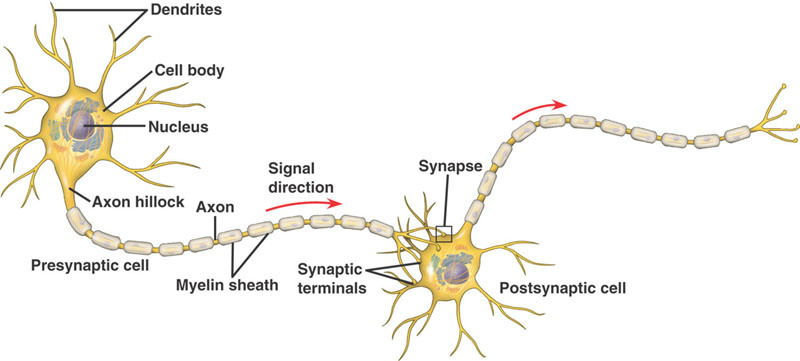

Source: [The Kurzweil Library, Neuron Structure](https://www.thekurzweillibrary.com/images/neuron_structure.jpg).


A neural network consist of interconnected computational units called **neurons** (or **nodes**) that communicate with one another by passing information through weighted connections. Just as biological neurons receive, process, and transmit signals, artificial neurons perform mathematical operations to transform input data into meaningful outputs.

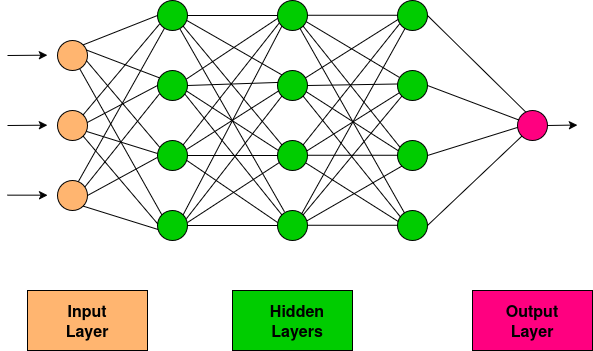

Source: Created by Authors


Unlike traditional algorithms that rely on explicit, hand-coded rules, they automatically learn to approximate complex, non-linear functions directly from raw data. They achieve this by passing inputs through interconnected layers of nodes, iteratively adjusting the mathematical weights between them to minimize prediction errors. Ultimately, training a neural network is an optimization process where the algorithm tunes these parameters to accurately map relationships between inputs and outputs.


In [ ]:
import pylab
from matplotlib import gridspec
from sklearn.datasets import make_classification
import numpy as np
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets
import pickle
import os
import gzip

# pick the seed for reproducability - change it to explore the effects of random variations
np.random.seed(1)
import random

## Perceptron

Frank Rosenblatt from the Cornell Aeronautical Laboratory in 1957 made the first attempts at implementing something similar to an artificial neural network. This was a hardware implementation designed to recognize primitive geometric shapes such as triangles, squares, and circles (Source: Rosenblatt, F. (1958). *The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain*. Psychological Review, 65(6), 386–408. [Read the paper here](https://www.ling.upenn.edu/courses/cogs501/Rosenblatt1958.pdf)).

### Perceptron Model

Suppose we have $N$ features in our model, in which case the input vector would be a vector of size $N$. A perceptron is a **binary classification** model, i.e. it can distinguish between two classes of input data. We will assume that for each input vector $x$ the output of our perceptron would be either $+1$ or $-1$, depending on the class. The output will be computed using the formula:

$$y(x) = f(w^Tx)$$

where $f$ is a step activation function

$$f(x) = \begin{cases} +1 & x \ge 0 \\ -1 & x < 0 \end{cases}$$

In practice, the perceptron uses these weights to draw a straight decision boundary that splits the data into two distinct regions. By evaluating which side of this boundary a new data point falls on, the step function instantly assigns it to the correct class.

### Training Algorithm

In order to train the perceptron, we need to find out weights $\mathbf{w}$ that will minimize the error. The error is defined using **perceptron criteria**:

$$E(\mathbf{w}) = -\sum_{n \in \mathcal{M}}\mathbf{w}^{\mathrm{T}}\mathbf{x}_{n}t_{n}$$

  * $t_{n} \in \{-1, +1\}$ for negative and positive training samples, respectively
  * $\mathcal{M}$ - a set of wrongly classified examples
  
We will use the process of **gradient descent**. Starting with some initial random weights $\mathbf{w}^{(0)}$, we will adjust weights on each step of the training using the gradient of $E$:

$$\mathbf{w}^{\tau + 1}=\mathbf{w}^{\tau} - \eta \nabla E(\mathbf{w}) = \mathbf{w}^{\tau} + \eta\sum_{n \in \mathcal{M}}\mathbf{x}_{n} t_{n}$$

where $\eta$ is a **learning rate**, and $\tau\in\mathbb{N}$ - number of iteration.

Let's define this algorithm in Python:

### Let's work with a toy dataset

To understand how the perceptron learns, we will generate a simple, synthetic 2D dataset. We will create $n$ samples with 2 features ($x_1$ and $x_2$) that are **linearly separable**. This means we can draw a single straight line to perfectly divide the two classes.

We will use scikit-learn's `make_classification` to generate the data, convert the labels from `0/1` to `-1/+1` (to match our perceptron's step function output), and split the data into training and testing sets.

In [1]:
n = 50
X, Y = make_classification(n_samples = n, n_features=2,
                           n_redundant=0, n_informative=2, flip_y=0)
Y = Y*2-1 # convert initial 0/1 values into -1/1
X = X.astype(np.float32); Y = Y.astype(np.int32) # features - float, label - int

# Split the dataset into training and test
train_x, test_x = np.split(X, [ n*8//10])
train_labels, test_labels = np.split(Y, [n*8//10])
print("Features:\n",train_x[0:4])
print("Labels:\n",train_labels[0:4])

NameError: name 'make_classification' is not defined

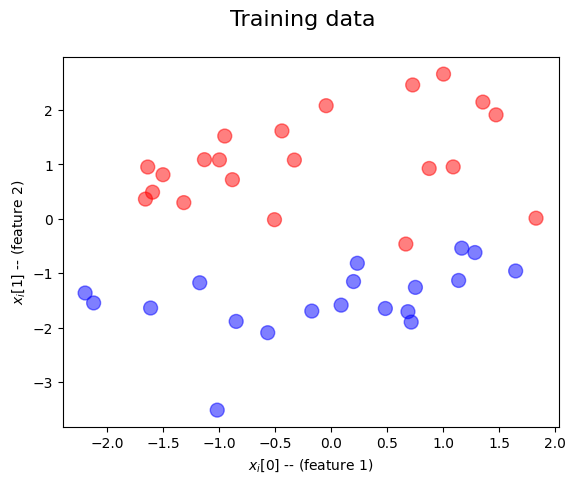

In [ ]:
def plot_dataset(suptitle, features, labels):
    fig, ax = pylab.subplots(1, 1, figsize=(6, 5))
    fig.suptitle(suptitle, fontsize=14)
    ax.set_xlabel('$x_i[0]$ -- (feature 1)')
    ax.set_ylabel('$x_i[1]$ -- (feature 2)')
    colors = ['r' if l>0 else 'b' for l in labels]
    ax.scatter(features[:, 0], features[:, 1], marker='o', c=colors, s=80, alpha=0.6)
    ax.grid(True, alpha=0.3)
    pylab.tight_layout()
    fig.show()

plot_dataset('Training data', train_x, train_labels)

The plot above visualizes our training data. As you can see, we have two distinct classes (represented by red and blue dots) that are clearly separated. Because there is a distinct gap between the two groups, a single-layer perceptron will be able to learn a straight decision boundary to perfectly classify this dataset.

Now that we have our data, let's look at how the perceptron actually finds this boundary using its training algorithm.

In [ ]:
pos_examples = np.array([ [t[0], t[1], 1] for i,t in enumerate(train_x)
                          if train_labels[i]>0])
neg_examples = np.array([ [t[0], t[1], 1] for i,t in enumerate(train_x)
                          if train_labels[i]<0])
print(pos_examples[0:3])

[[-1.50100958  0.81034589  1.        ]
 [-1.59405196  0.48902771  1.        ]
 [-0.43857044  1.61558831  1.        ]]


In [ ]:
def train(positive_examples, negative_examples, num_iterations = 100, learning_rate = 0.01):
    num_dims = positive_examples.shape[1]

    # Initialize weights.
    # We initialize with 0 for simplicity, but random initialization is also a good idea
    weights = np.zeros((num_dims,1))

    pos_count = positive_examples.shape[0]
    neg_count = negative_examples.shape[0]

    report_frequency = 10

    for i in range(num_iterations):
        # Pick one positive and one negative example
        pos = random.choice(positive_examples)
        neg = random.choice(negative_examples)

        z = np.dot(pos, weights)
        if z < 0: # positive example was classified as negative
            weights = weights + learning_rate * pos.reshape(weights.shape)

        z  = np.dot(neg, weights)
        if z >= 0: # negative example was classified as positive
            weights = weights - learning_rate * neg.reshape(weights.shape)

        # Periodically, print out the current accuracy on all examples
        if i % report_frequency == 0:
            pos_out = np.dot(positive_examples, weights)
            neg_out = np.dot(negative_examples, weights)
            pos_correct = (pos_out >= 0).sum() / float(pos_count)
            neg_correct = (neg_out < 0).sum() / float(neg_count)
            print("Iteration={}, pos correct={}, neg correct={}".format(i,pos_correct,neg_correct))

    return weights

**Note on Learning Rate**: The `learning_rate` parameter (default `0.01`) controls how much we adjust the weights during each training step. This implements the gradient descent update formula:

$$\mathbf{w}^{\tau + 1}=\mathbf{w}^{\tau} + \eta \mathbf{x}_{n} t_{n}$$

- A larger learning rate (e.g., `1.0`) makes the perceptron learn faster but may overshoot the optimal solution
- A smaller learning rate (e.g., `0.001`) learns more slowly but may converge more precisely
- You can experiment by calling: `train(pos_examples, neg_examples, learning_rate=0.1)`


In [ ]:
wts = train(pos_examples,neg_examples)
print(wts.transpose())

Iteration=0, pos correct=0.6190476190476191, neg correct=1.0
Iteration=10, pos correct=1.0, neg correct=0.8421052631578947
Iteration=20, pos correct=1.0, neg correct=0.8421052631578947
Iteration=30, pos correct=0.9047619047619048, neg correct=1.0
Iteration=40, pos correct=0.9523809523809523, neg correct=1.0
Iteration=50, pos correct=0.9523809523809523, neg correct=1.0
Iteration=60, pos correct=1.0, neg correct=0.9473684210526315
Iteration=70, pos correct=0.9523809523809523, neg correct=1.0
Iteration=80, pos correct=0.9523809523809523, neg correct=1.0
Iteration=90, pos correct=0.9047619047619048, neg correct=1.0
[[-0.00552393  0.04754574  0.01      ]]


In [ ]:
def plot_boundary(positive_examples, negative_examples, weights):
    if np.isclose(weights[1], 0):
        if np.isclose(weights[0], 0):
            x = y = np.array([-6, 6], dtype = 'float32')
        else:
            y = np.array([-6, 6], dtype='float32')
            x = -(weights[1] * y + weights[2])/weights[0]
    else:
        x = np.array([-6, 6], dtype='float32')
        y = -(weights[0] * x + weights[2])/weights[1]

    pylab.xlim(-6, 6)
    pylab.ylim(-6, 6)
    pylab.plot(positive_examples[:,0], positive_examples[:,1], 'bo')
    pylab.plot(negative_examples[:,0], negative_examples[:,1], 'ro')
    pylab.plot(x, y, 'g', linewidth=2.0)
    pylab.show()

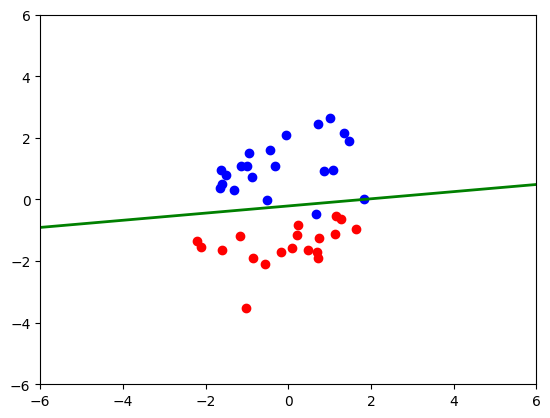

In [ ]:
plot_boundary(pos_examples,neg_examples,wts)

Iteration=0, pos correct=0.42857142857142855, neg correct=0.8421052631578947
Iteration=10, pos correct=0.9523809523809523, neg correct=1.0
Iteration=20, pos correct=1.0, neg correct=0.8947368421052632
Iteration=30, pos correct=0.9047619047619048, neg correct=1.0
Iteration=40, pos correct=0.9047619047619048, neg correct=1.0
Iteration=50, pos correct=0.9047619047619048, neg correct=1.0
Iteration=60, pos correct=1.0, neg correct=1.0
Iteration=70, pos correct=1.0, neg correct=1.0
Iteration=80, pos correct=1.0, neg correct=1.0
Iteration=90, pos correct=1.0, neg correct=1.0
Iteration=0, pos correct=0.6190476190476191, neg correct=0.8421052631578947
Iteration=10, pos correct=0.9523809523809523, neg correct=1.0
Iteration=20, pos correct=0.9523809523809523, neg correct=1.0
Iteration=30, pos correct=0.9523809523809523, neg correct=1.0
Iteration=40, pos correct=0.9523809523809523, neg correct=1.0
Iteration=50, pos correct=1.0, neg correct=0.8947368421052632
Iteration=60, pos correct=1.0, neg corr

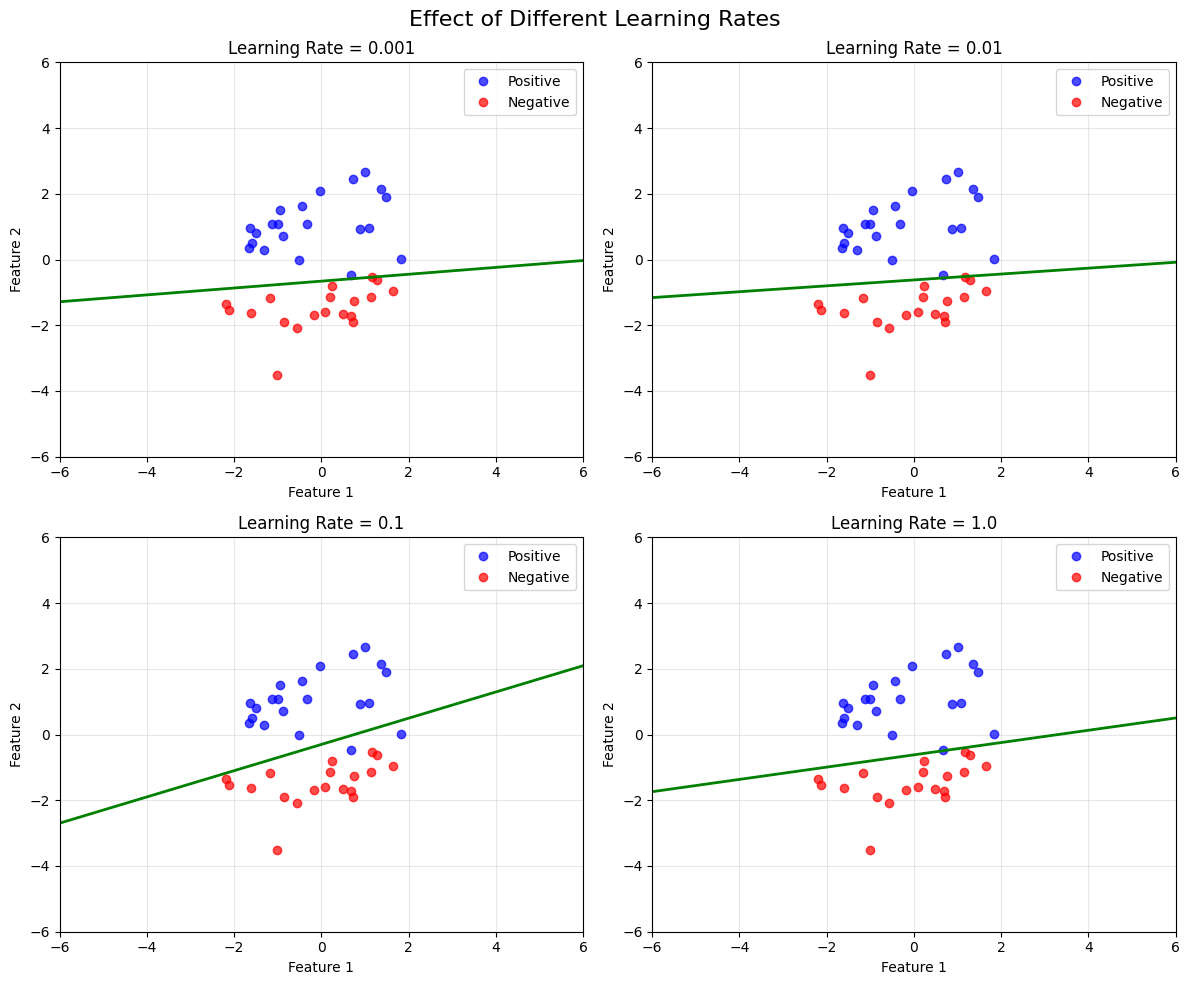

In [ ]:
# Compare different learning rates
learning_rates = [0.001, 0.01, 0.1, 1.0]
fig, axes = pylab.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Effect of Different Learning Rates', fontsize=14)

for idx, lr in enumerate(learning_rates):
    ax = axes[idx // 2, idx % 2]

    # Train with this learning rate
    weights_lr = train(pos_examples, neg_examples, num_iterations=100, learning_rate=lr)

    # Plot decision boundary
    if np.isclose(weights_lr[1], 0):
        if np.isclose(weights_lr[0], 0):
            x = y = np.array([-6, 6], dtype='float32')
        else:
            y = np.array([-6, 6], dtype='float32')
            x = -(weights_lr[1] * y + weights_lr[2])/weights_lr[0]
    else:
        x = np.array([-6, 6], dtype='float32')
        y = -(weights_lr[0] * x + weights_lr[2])/weights_lr[1]

    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.plot(pos_examples[:, 0], pos_examples[:, 1], 'bo', label='Positive', alpha=0.7, markersize=5)
    ax.plot(neg_examples[:, 0], neg_examples[:, 1], 'ro', label='Negative', alpha=0.7, markersize=5)
    ax.plot(x, y, 'g-', linewidth=2)
    ax.set_title(f'LR = {lr}', fontsize=11)
    ax.set_xlabel('Feature 1', fontsize=9)
    ax.set_ylabel('Feature 2', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

pylab.tight_layout()
pylab.show()

In [ ]:
def train_and_plot_with_lr(learning_rate=0.01):
    """Train perceptron with specified learning rate and plot results"""
    weights_lr = train(pos_examples, neg_examples, num_iterations=100, learning_rate=learning_rate)

    fig, (ax1, ax2) = pylab.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Decision boundary
    if np.isclose(weights_lr[1], 0):
        if np.isclose(weights_lr[0], 0):
            x = y = np.array([-6, 6], dtype='float32')
        else:
            y = np.array([-6, 6], dtype='float32')
            x = -(weights_lr[1] * y + weights_lr[2])/weights_lr[0]
    else:
        x = np.array([-6, 6], dtype='float32')
        y = -(weights_lr[0] * x + weights_lr[2])/weights_lr[1]

    ax1.set_xlim(-6, 6)
    ax1.set_ylim(-6, 6)
    ax1.plot(pos_examples[:, 0], pos_examples[:, 1], 'bo', label='Positive', s=100, alpha=0.6)
    ax1.plot(neg_examples[:, 0], neg_examples[:, 1], 'ro', label='Negative', s=100, alpha=0.6)
    ax1.plot(x, y, 'g-', linewidth=3, label='Decision Boundary')
    ax1.set_title(f'Decision Boundary (lr={learning_rate})', fontsize=14)
    ax1.set_xlabel('Feature 1')
    ax1.set_ylabel('Feature 2')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Weight values
    ax2.bar(['w0', 'w1', 'bias'], weights_lr.flatten(), color=['blue', 'green', 'red'], alpha=0.7)
    ax2.set_title('Final Weight Values', fontsize=14)
    ax2.set_ylabel('Weight Value')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    pylab.tight_layout()
    pylab.show()

    print(f"Final weights: {weights_lr.flatten()}")

# Create interactive widget
interact(train_and_plot_with_lr,
         learning_rate=widgets.FloatSlider(value=0.01, min=0.001, max=1.0, step=0.001,
                                          description='Learning Rate:', continuous_update=False))


NameError: name 'interact' is not defined


### Limitations of the Perceptron

As you have seen above, perceptron is a **linear classifier**. It can distinguish between two classes well if they are **linearly separable**, i.e. can be separated by a straight line. Otherwise, perceptron training process will not converge.

A most obvious example of a problem that cannot be solved by a perceptron is so-called **XOR problem**. We want our perceptron to learn the XOR boolean function, which has the following truth table:

|   | 0 | 1 |
|---|---|---|
| 0 | 0 | 1 |
| 1 | 1 | 0 |

Let's try and do that! We will manually populate all positive and negative training samples, and then call our train function defined above:

In [ ]:
pos_examples_xor = np.array([[1,0,1],[0,1,1]])
neg_examples_xor = np.array([[1,1,1],[0,0,1]])

snapshots_xor = train_graph(pos_examples_xor,neg_examples_xor,1000)
def pl2(step): plotit(pos_examples_xor,neg_examples_xor,snapshots_xor,step)

In [ ]:
interact(pl2, step=widgets.IntSlider(value=0, min=0, max=len(snapshots)-1))

As you can see from the graph above, the accuracy never goes above 75%, because it is impossible to draw a straight line in such a way as to get all possible examples right.

The XOR problem is a classical example of perceptron limitations, and it was pointed out by Marvin Minsky and Seymour Papert in 1969 in their book Perceptrons). This observation limited research in the area of neural networks for almost 10 years, even though - and we will see this in the next section of our course - multi-layered perceptrons are perfectly capable of solving such problems.

## Multi-Layer Perceptrons and Forward Propagations

While a single perceptron is a great conceptual starting point, it has a fatal flaw: it can only learn linear boundaries. If your data cannot be separated by a straight line, a single neuron will completely fail.

To solve real-world problems, we must stack multiple neurons together to form a **Multi-Layer Perceptron (MLP)**. An MLP is a fully connected feedforward neural network. "Fully connected" means that every neuron in one layer connects to every single neuron in the next layer.

### The Architecture of an MLP
An MLP consists of three distinct types of layers:
1.  **Input Layer:** The raw data entering the network. The number of neurons here equals the number of features in your dataset.
2.  **Hidden Layers:** The processing engine of the network. A network can have one hidden layer or hundreds. This is where the activation functions create non-linearity.
3.  **Output Layer:** The final prediction. For binary classification, this is a single neuron. For multi-class classification, it contains multiple neurons representing probability scores.

### The Math: Forward Propagation in Matrices
In our single neuron example, we calculated the math one input at a time using $z = wx + b$. In an MLP, we have hundreds of neurons and thousands of weights. Calculating them one by one using `for` loops in Python would be incredibly slow.

Instead, we use **Linear Algebra (Vectorization)** to calculate an entire layer of neurons all at exactly the same time.

For any given hidden layer $l$, the forward propagation mathematically looks like this:

**1. The Linear Step (Matrix Multiplication):**

$$Z^{[l]} = W^{[l]} \cdot A^{[l-1]} + b^{[l]}$$

**2. The Activation Step:**

$$A^{[l]} = g^{[l]}(Z^{[l]})$$

### Breaking Down the Variables:
*   $l$: The current layer we are calculating.
*   $W^{[l]}$: The **Weight Matrix** for layer $l$. If the current layer has 5 neurons, and the previous layer had 3 neurons, this will be a $5 \times 3$ matrix containing all the connected weights.
*   $A^{[l-1]}$: The **Activation Vector** coming from the *previous* layer. (For the very first hidden layer, $A^{[0]}$ is just your raw input data, $X$).
*   $b^{[l]}$: The **Bias Vector** for the current layer.
*   $Z^{[l]}$: The resulting raw, weighted sums for every neuron in the current layer.
*   $g^{[l]}$: The **Activation Function** (like ReLU or Sigmoid) applied to the current layer.
*   $A^{[l]}$: The final output vector of the current layer, which immediately becomes the input for the next layer.

### The Chronological Flow
During a forward pass, this two-step calculation cascades through the network:
1.  Input $X$ enters the network.
2.  Layer 1 computes $Z^{[1]}$ and applies activation to get $A^{[1]}$.
3.  Layer 2 takes $A^{[1]}$, computes $Z^{[2]}$, and applies activation to get $A^{[2]}$.
4.  This repeats until the final layer outputs the ultimate prediction, $\hat{y}$.

By stacking these matrix operations and applying non-linear activation functions in between them, an MLP can theoretically approximate *any* mathematical function, no matter how complex!

## Forward Propagation

Forward propagation (often called the **forward pass**) is the core mechanism of how a neural network makes decisions. It is the chronological process of pushing input data from the input layer, through any hidden layers, to the final output layer to generate a prediction.

Think of it as an assembly line. Raw materials enter at the start, pass through several processing stations, and emerge as a finished product. For example, if we are building a simple classification model for a healthcare solution, our inputs ($X$) might be standardized patient metrics (like heart rate and blood pressure), and the output ($y$) is the network's prediction of a specific risk category.

### The Two Steps of a Forward Pass
Inside every single artificial neuron during the forward pass, two sequential mathematical operations occur:

**1. The Linear Transformation (The Weighted Sum)**
The neuron receives inputs from the previous layer, multiplies each input by its corresponding weight, and adds a bias.
$$z = W \cdot X + b$$
*   $X$: The input vector (the data we are feeding in).
*   $W$: The weights (determining how important each input is).
*   $b$: The bias (a baseline adjustment).

**2. The Activation (The Non-Linearity)**
If we only used the step above, our network would just be a simple linear regression model. To allow the network to learn complex, real-world patterns, we pass that weighted sum ($z$) through an **activation function** ($f$):
$$a = f(z)$$
*   $a$: The final output (activation) of this specific neuron, which is then sent forward to become the input for the next layer.

This two-step cycle cascades layer by layer until the final prediction is computed at the end of the network.

> **Important Note:** During forward propagation, **no learning actually happens**. The network is simply making a "guess" based on whatever its weights and biases currently are. To actually learn, we need to evaluate that guess and update the weights, which brings us to loss functions and backpropagation.

## Loss functions

In the previous step (Forward Propagation), our neural network made a prediction. But how do we know if that prediction was any good?

A **Loss Function** (often called a Cost Function or Error Function) is the mathematical way we measure how "wrong" the network's guess is compared to the actual, true answer in our dataset. If forward propagation is a student taking a test, the loss function is the teacher grading it.

The goal of training a neural network is singular: **minimize the loss**. The lower the loss, the closer our predictions are to reality.

### Common Types of Loss Functions
We don't use the same grading rubric for every type of test. The loss function you choose depends entirely on the type of machine learning problem you are solving:

**1. Mean Squared Error (MSE) — For Regression**
Use MSE when you are predicting a continuous number (e.g., predicting the price of a house or the exact temperature). It calculates the average of the squared differences between the actual true values ($y$) and the network's predicted values ($\hat{y}$).
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
*   By squaring the difference, we ensure that negative and positive errors don't cancel each other out. It also heavily penalizes predictions that are wildly off the mark (since large errors get squared into even larger numbers).

**2. Cross-Entropy Loss — For Classification**
Use Cross-Entropy when your network needs to categorize data into distinct buckets (e.g., binary classification like the perceptron model, or determining if an image is a "cat" or "dog").
*   Instead of looking at the raw numerical distance between numbers like MSE, Cross-Entropy measures the performance of a model where the output is a probability value between 0 and 1.
*   If the true class is a positive diagnosis (1), and the model predicts a probability of 0.01 (meaning it is very confident that it is *not* a positive diagnosis), the Cross-Entropy loss will penalize the model heavily for being so confidently wrong.

> **What's Next?** Once the loss function computes this mathematical "error score," we finally have the information we need to make the network smarter. We take this error and pass it backward through the network to figure out which weights caused the mistake—a process called **Backpropagation**.

## Optimizations

We have made a guess (Forward Propagation), we have measured exactly how wrong that guess is (Loss Function), and we have used calculus to figure out which direction we need to shift our weights to fix the error (Backpropagation).

Now, we actually have to take action and change the weights. This is the job of the **Optimizer**.

Think of training a neural network like a blindfolded hiker trying to find the lowest point in a vast, hilly valley.
*   Your current altitude is the **Loss**. You want to get to the bottom (zero loss).
*   Feeling the slope of the ground under your feet is **Backpropagation** (finding the gradients).
*   Deciding exactly how large of a step to take down that slope is the **Optimizer**.

### The Core Math: Gradient Descent
The most fundamental optimization algorithm is called Gradient Descent. The formula to update a single weight looks like this:

$$W_{new} = W_{old} - \alpha \cdot \frac{\partial L}{\partial W}$$

*   $W$: The specific weight we are updating.
*   $\frac{\partial L}{\partial W}$: The gradient (the slope of the error). It tells us which way is "up." We subtract it because we want to go "down" the hill.
*   $\alpha$: The **Learning Rate**. This is the single most important knob you will turn when training a model.

**The Goldilocks Problem of Learning Rates:**
The learning rate ($\alpha$) determines the size of the step the hiker takes.
*   If $\alpha$ is **too large**, the hiker takes massive leaps and might completely overshoot the bottom of the valley, bouncing up the other side. The model fails to learn.
*   If $\alpha$ is **too small**, the hiker takes microscopic baby steps. The model will eventually reach the bottom, but it might take weeks of computing time to do it.

### Modern Optimizers You Will Use
While vanilla Gradient Descent is great for learning, it can be slow and get stuck easily in complex landscapes. Modern deep learning uses upgraded versions of this concept:

**1. Stochastic Gradient Descent (SGD)**
Instead of looking at the entire dataset before taking a single step (which is computationally exhausting), SGD looks at a small, random "batch" of data, estimates the slope, and takes a quick step. It is a bit noisier and zig-zags down the hill, but it computes drastically faster.

**2. Adam (Adaptive Moment Estimation)**
This is the default optimizer for most modern neural networks. Adam improves upon SGD by adding the concept of **momentum**. Think of a snowball rolling down a hill; if it keeps going in the same direction, it gathers speed. Adam remembers previous steps and dynamically adjusts the learning rate for each individual weight as it goes. If the slope is consistently pointing the same way, Adam takes bigger steps to get there faster!

## Activation functions

If a neural network only relied on weights and biases (which are just linear equations), stacking multiple layers wouldn't accomplish anything. Mathematically, a dozen linear layers combined just collapse back down into one single linear layer. The network would only ever be able to understand straight lines.

**Activation Functions** are the solution. They are mathematical equations attached to each neuron that decide whether it should be "activated" (fired) or ignored. Crucially, they introduce **non-linearity**, allowing the neural network to bend those straight lines to learn complex, real-world patterns like curves, circles, and irregular boundaries.

Here are the most foundational and modern activation functions you need to know:

### 1. Sigmoid
The Sigmoid function takes any input number (from negative infinity to positive infinity) and squashes it into a tight range between $0$ and $1$.

$$f(x)=\frac{1}{1+e^{-x}}$$

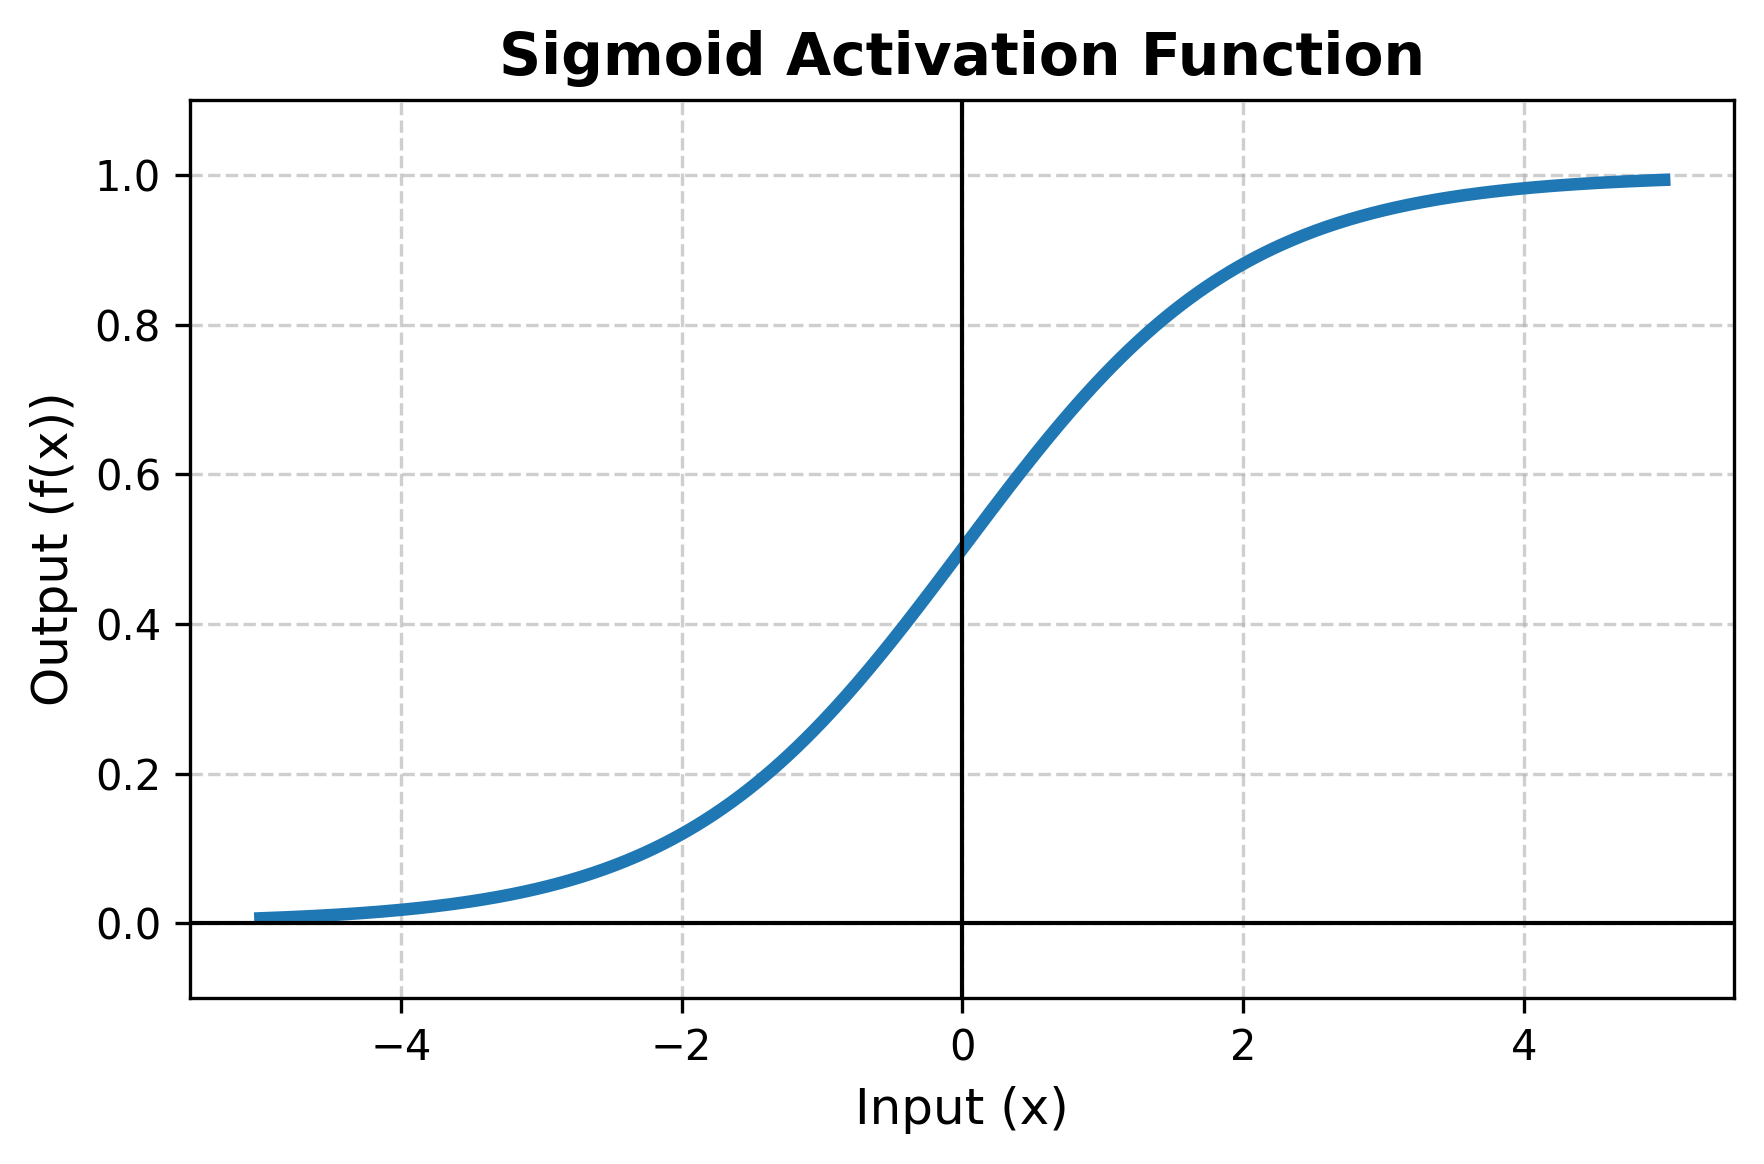

*   **Pros:** Because its output is between 0 and 1, it is perfect for models where we need to predict a probability (e.g., a binary classification of whether a scan shows a tumor or not).
*   **Cons:** It suffers from the "vanishing gradient" problem. For very high or very low inputs, the curve becomes incredibly flat. A flat curve means a slope of zero, and if the gradient is zero, the network stops learning.

---
### 2. Tanh (Hyperbolic Tangent)
Tanh is very similar to Sigmoid, but instead of squashing numbers between 0 and 1, it squashes them between $-1$ and $1$.

$$f(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}$$

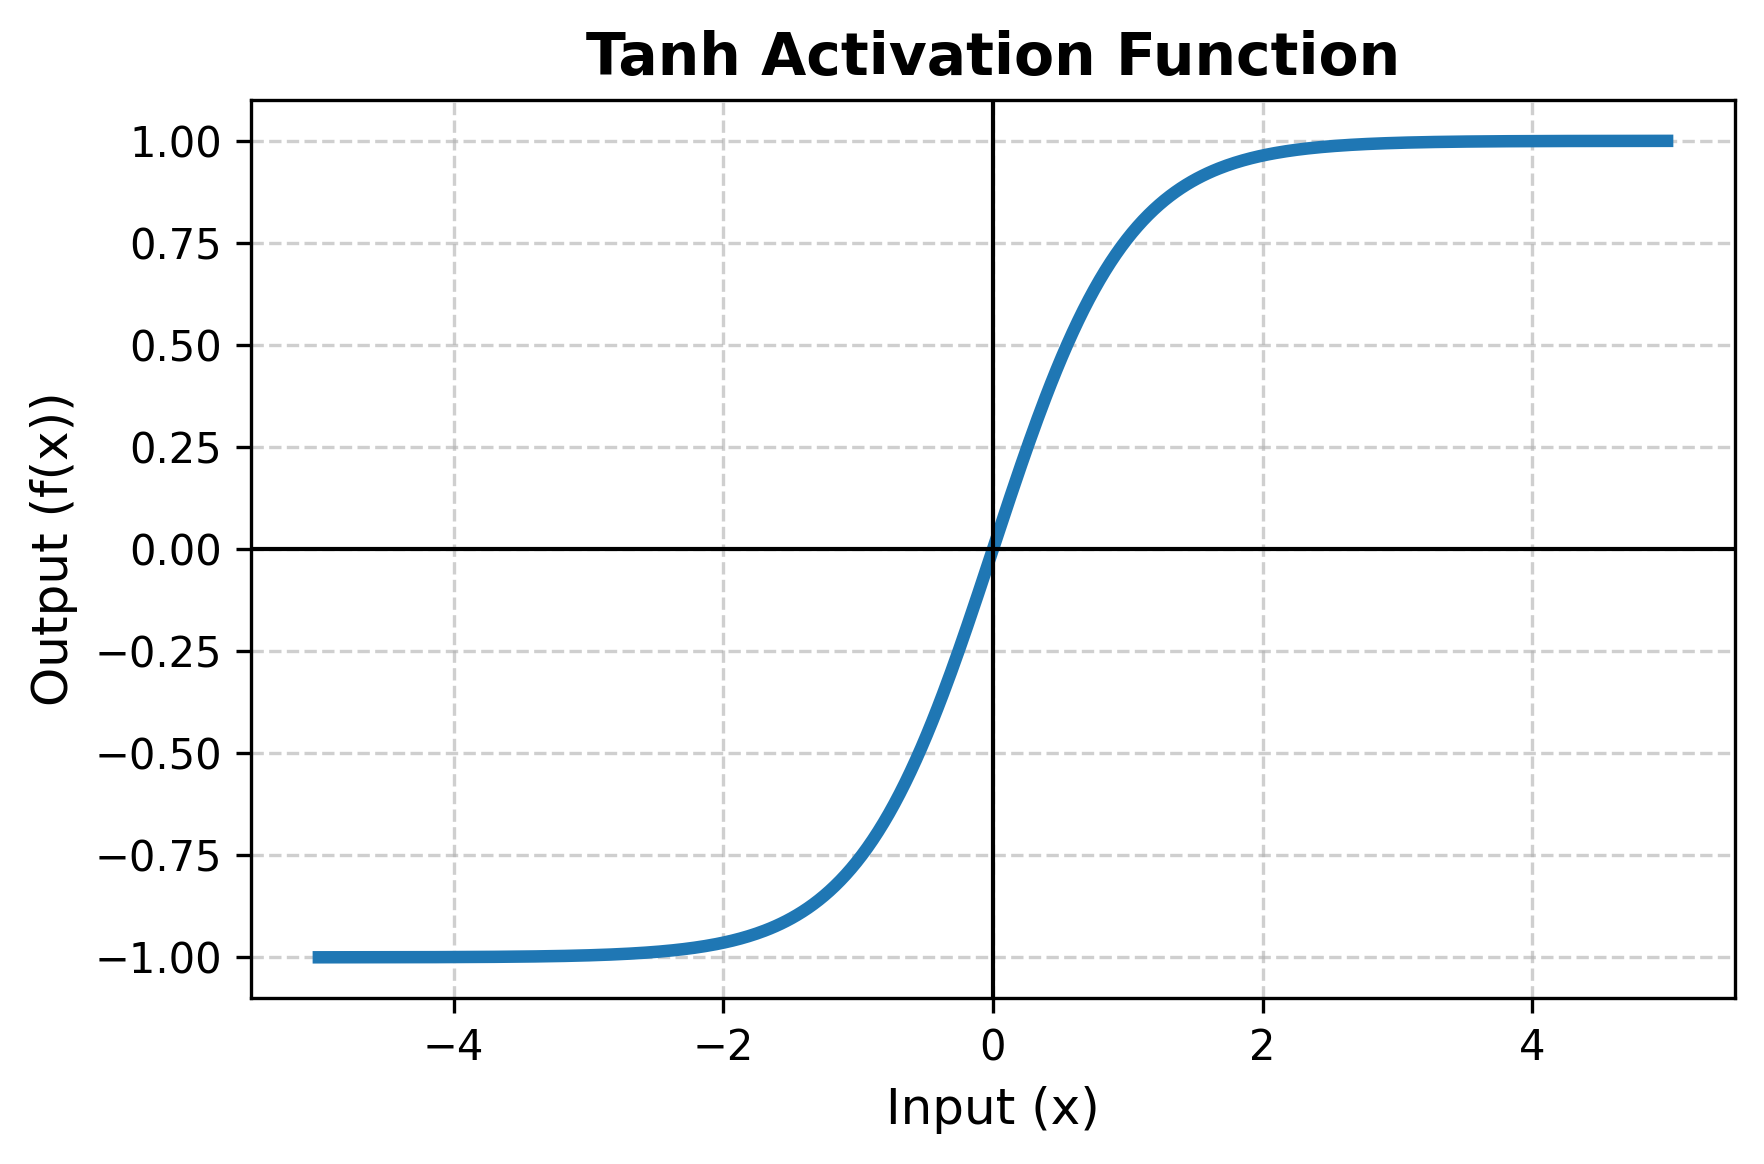

*   **Pros:** Unlike Sigmoid, Tanh is zero-centered. This means negative inputs will be mapped strongly negative, and zero inputs will be mapped near zero, which generally makes optimization easier and faster during training.
*   **Cons:** Like Sigmoid, it still suffers from vanishing gradients at the extreme ends of the curve.

---

### 3. ReLU (Rectified Linear Unit)
ReLU is incredibly simple but revolutionized deep learning. If the input is negative, it outputs exactly zero. If the input is positive, it outputs the raw input unchanged.

$$f(x)=\max(0,x)$$

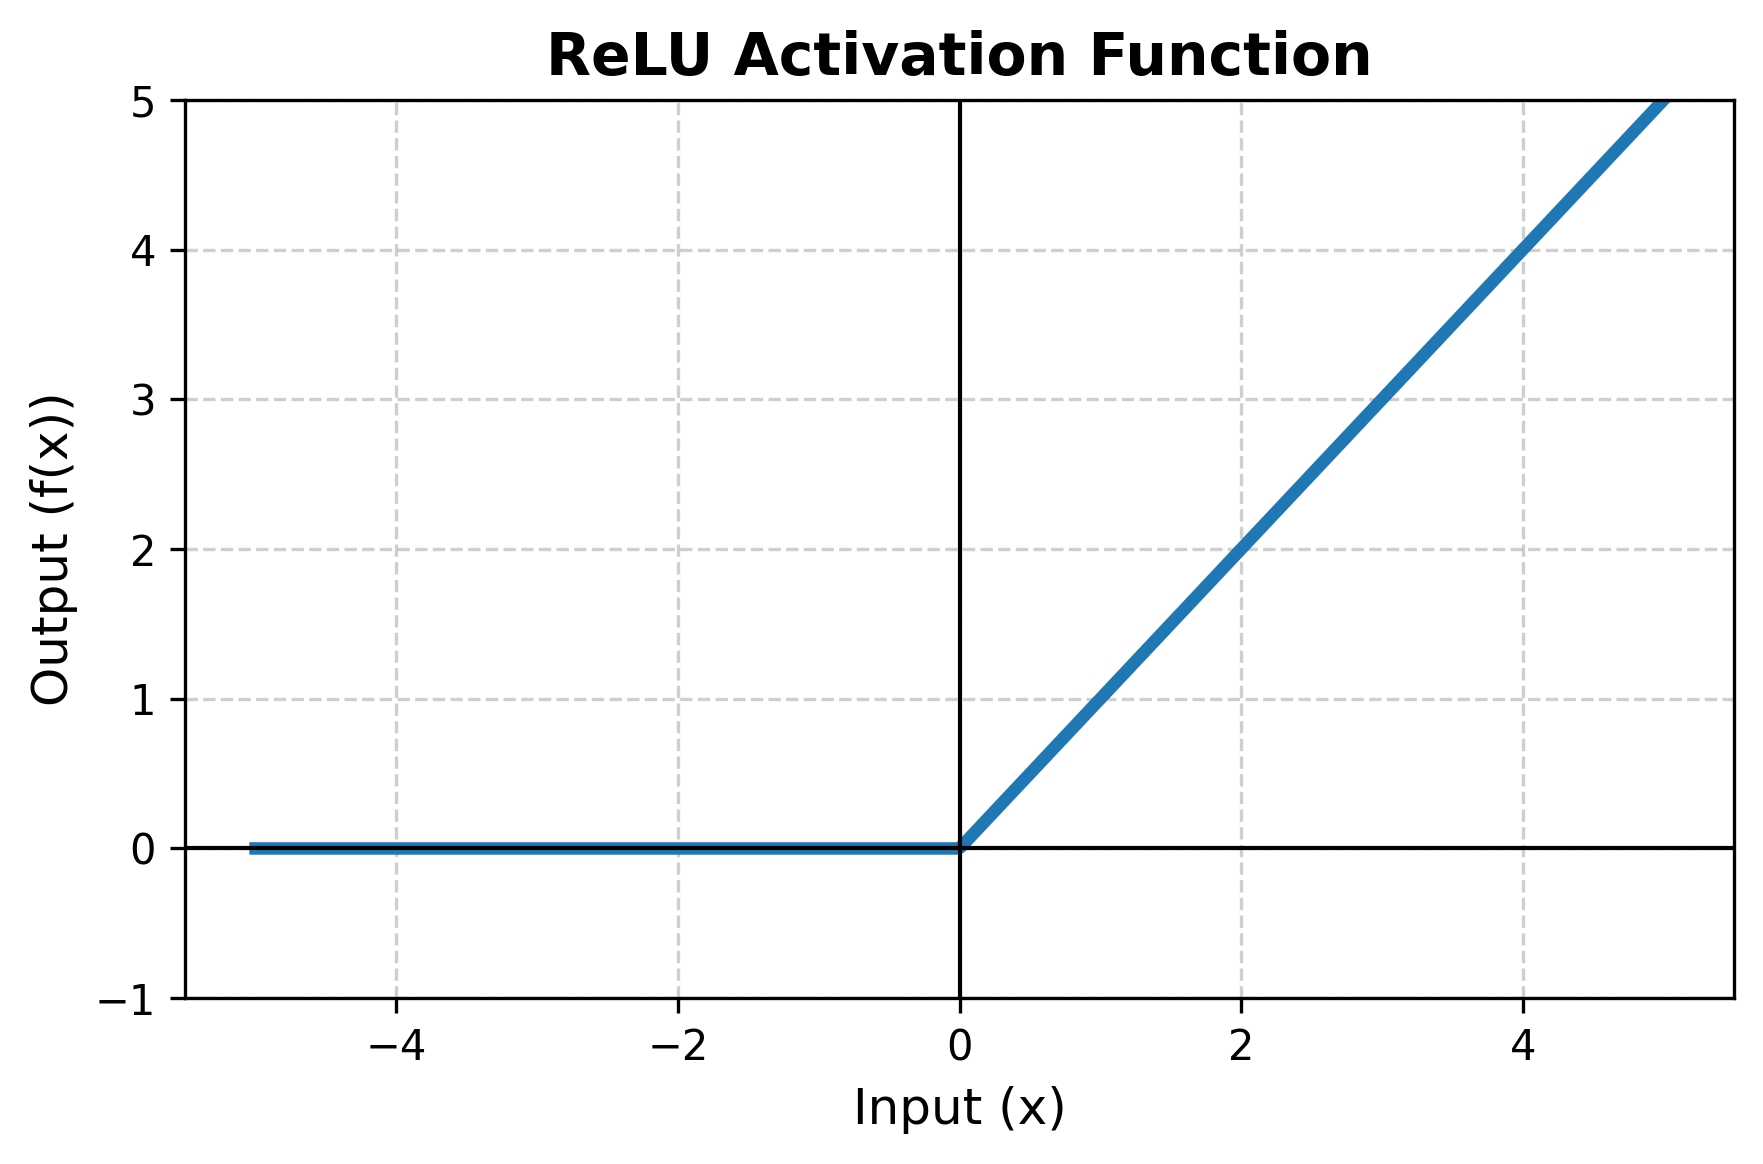

*   **Pros:** It is computationally cheap (just a simple threshold), which makes it highly efficient when deploying healthcare solutions on edge devices where processing power is limited. It also completely fixes the vanishing gradient problem for positive values.
*   **Cons:** "Dead Neurons." If a neuron's weights update in a way that causes it to only output negative numbers, ReLU will permanently turn it into a zero. That neuron dies and stops contributing to the network.

---
### 4. Leaky ReLU
An upgraded ReLU designed specifically to fix the "Dying ReLU" problem by keeping a tiny, constant slope for negative values instead of a hard zero.

$$f(x)=\max(\alpha x,x)$$

*(where $\alpha$ is a small constant, e.g., $0.01$)*

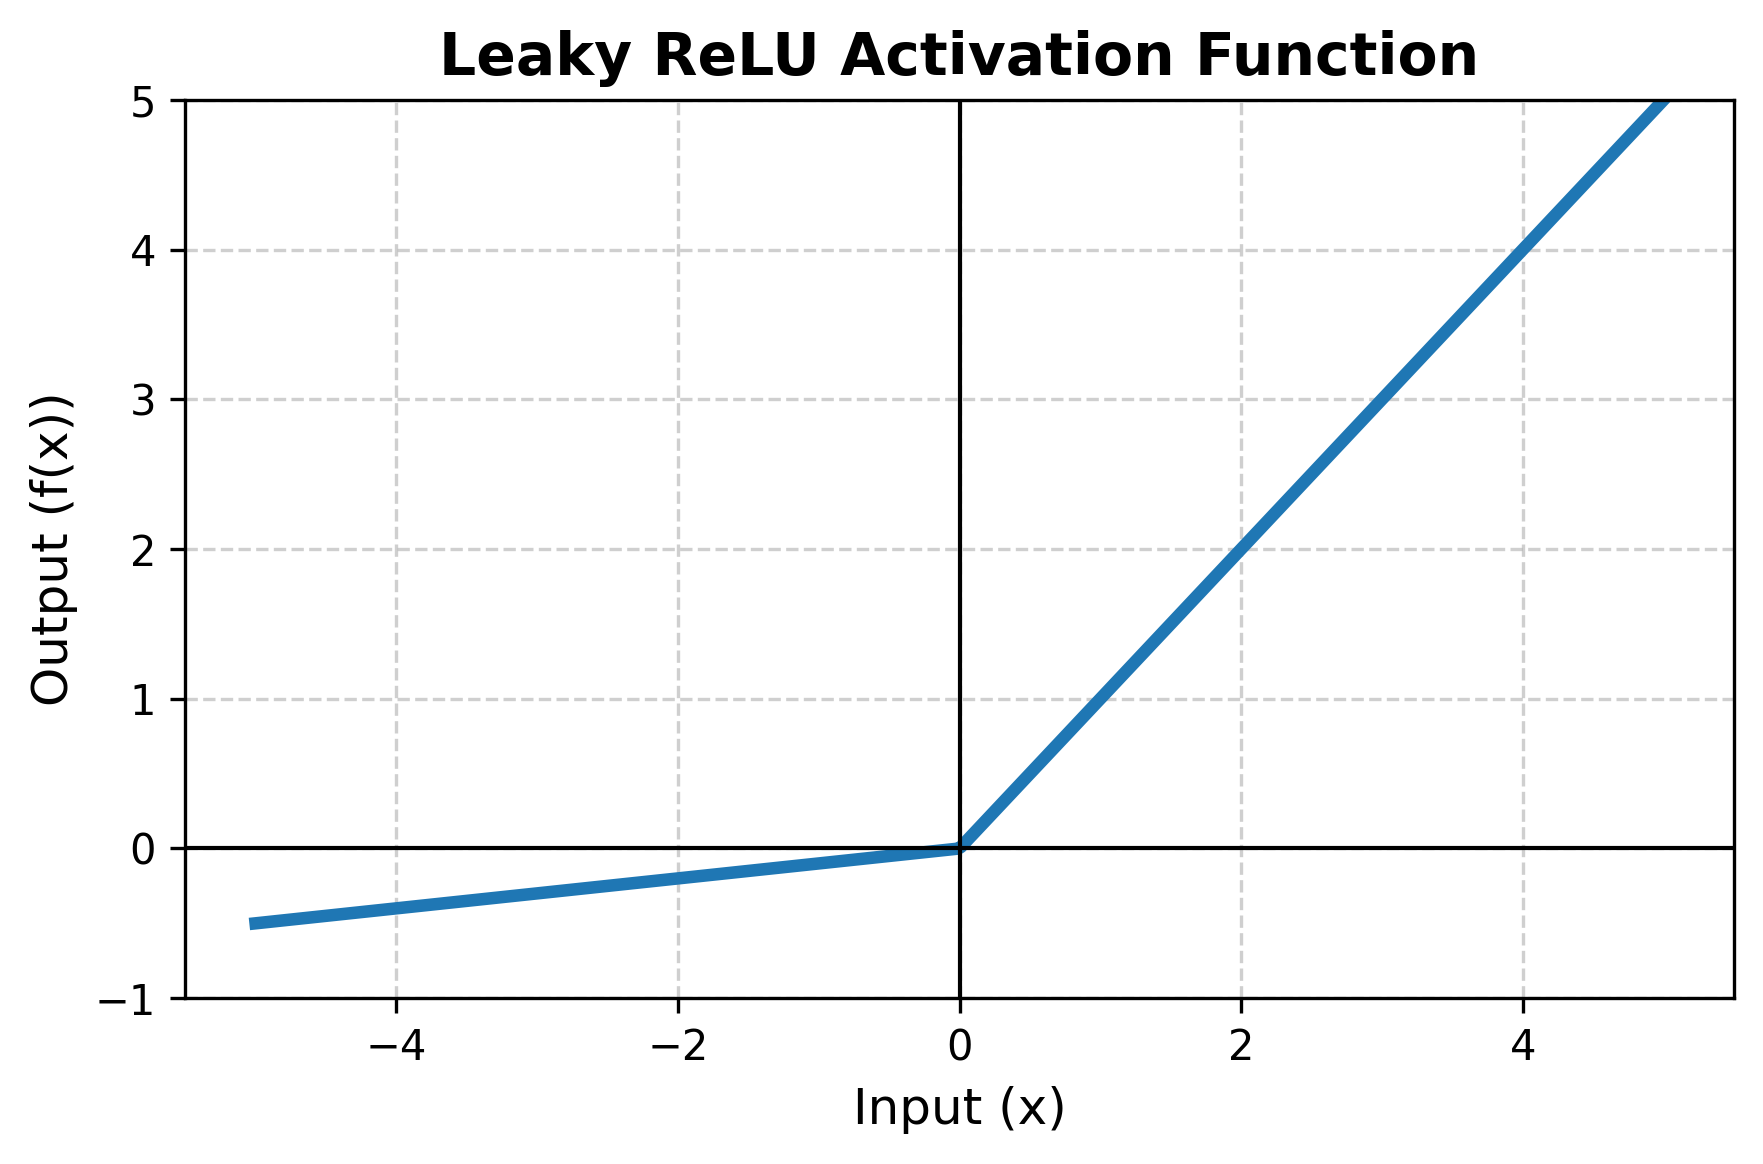

*   **Pros:** Prevents neuron death while maintaining the computational efficiency of standard ReLU.
*   **Cons:** The slope for negative values ($\alpha$) is a fixed hyperparameter that you must choose manually before training.

---
### 5. ELU (Exponential Linear Unit)
Similar to ReLU, but instead of a sharp angular corner at zero, it transitions smoothly into negative values using an exponential curve.

$$f(x)=\begin{cases}x&x>0\\\alpha(e^x-1)&x\le0\end{cases}$$

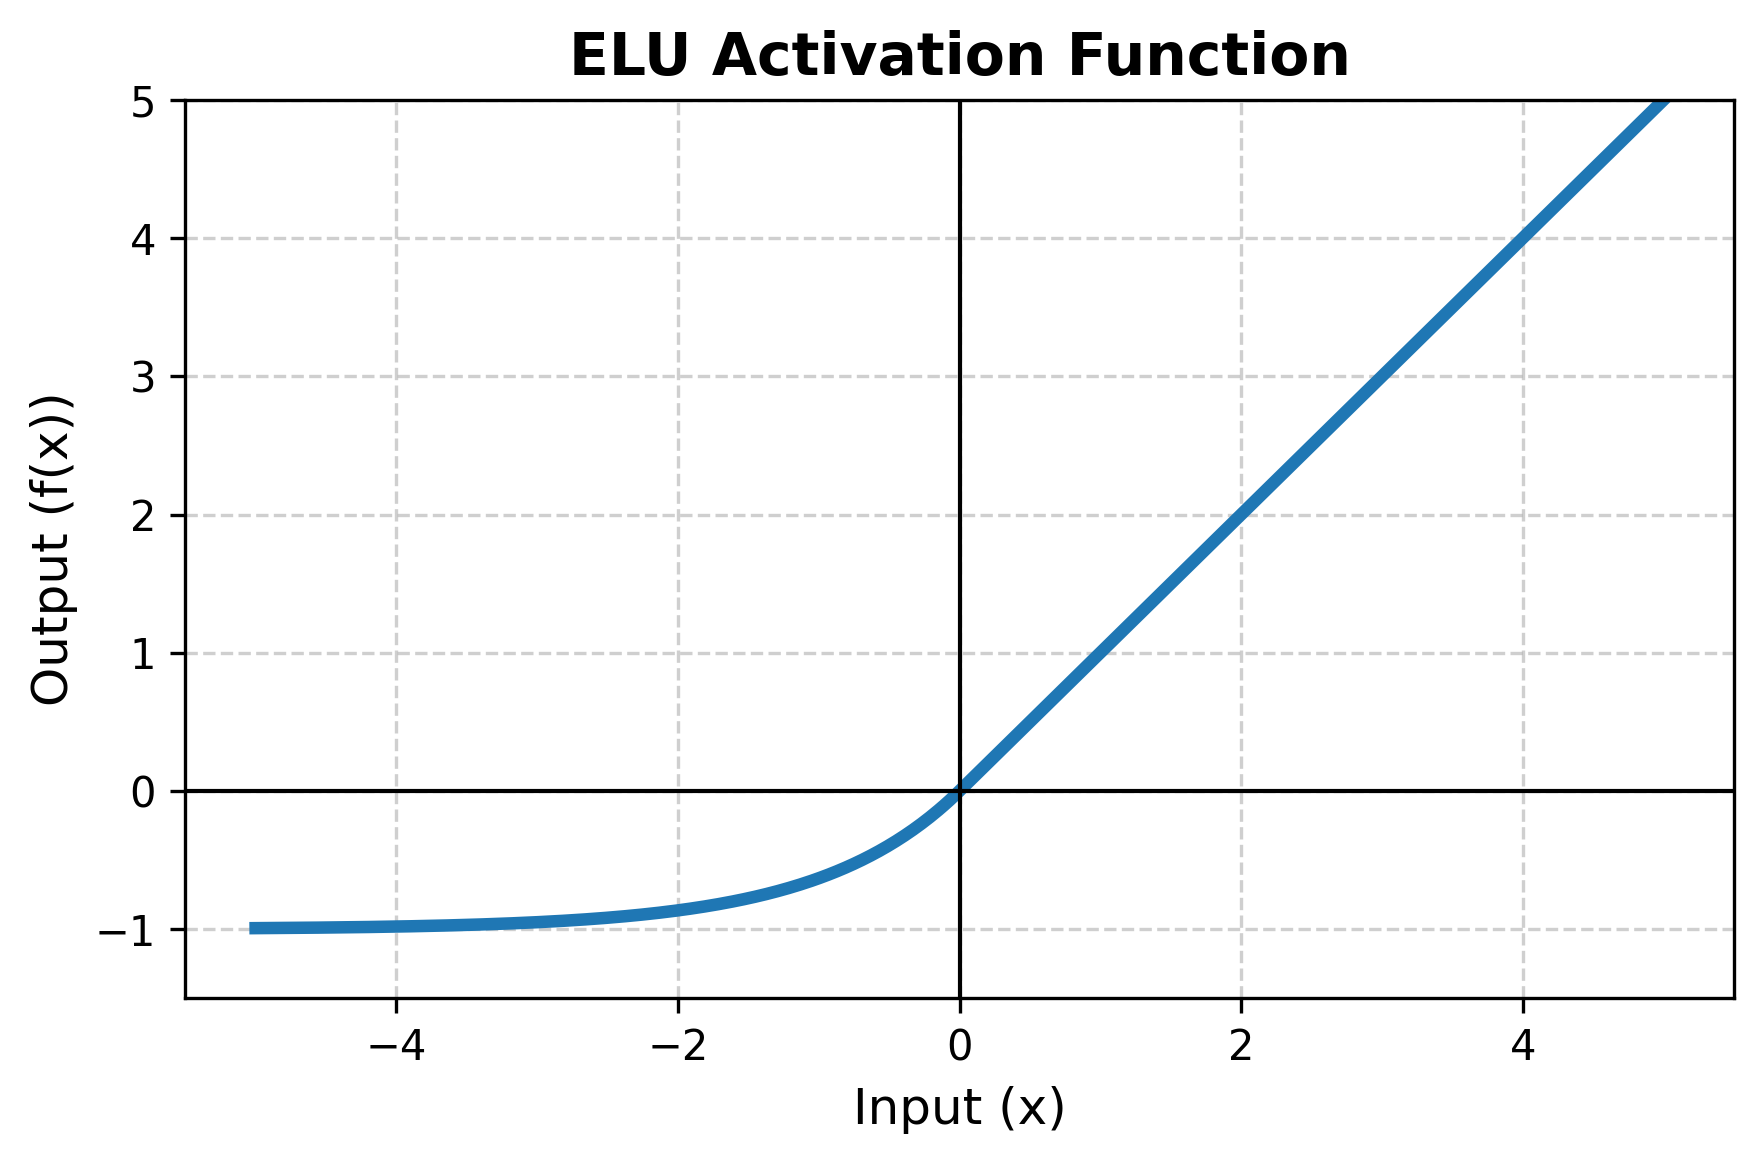

*   **Pros:** The smooth curve reduces noise during gradient updates, leading to faster convergence in deep networks.
*   **Cons:** Computing an exponential function ($e^x$) is computationally heavier than the simple maximum comparison used in ReLU.
---
### 6. Swish / SiLU (Sigmoid Linear Unit)
A self-gated activation function that multiplies the input by its own Sigmoid activation. It is non-monotonic, meaning it dips slightly below zero before climbing back up.

$$f(x)=x\cdot\sigma(x)=\frac{x}{1+e^{-x}}$$

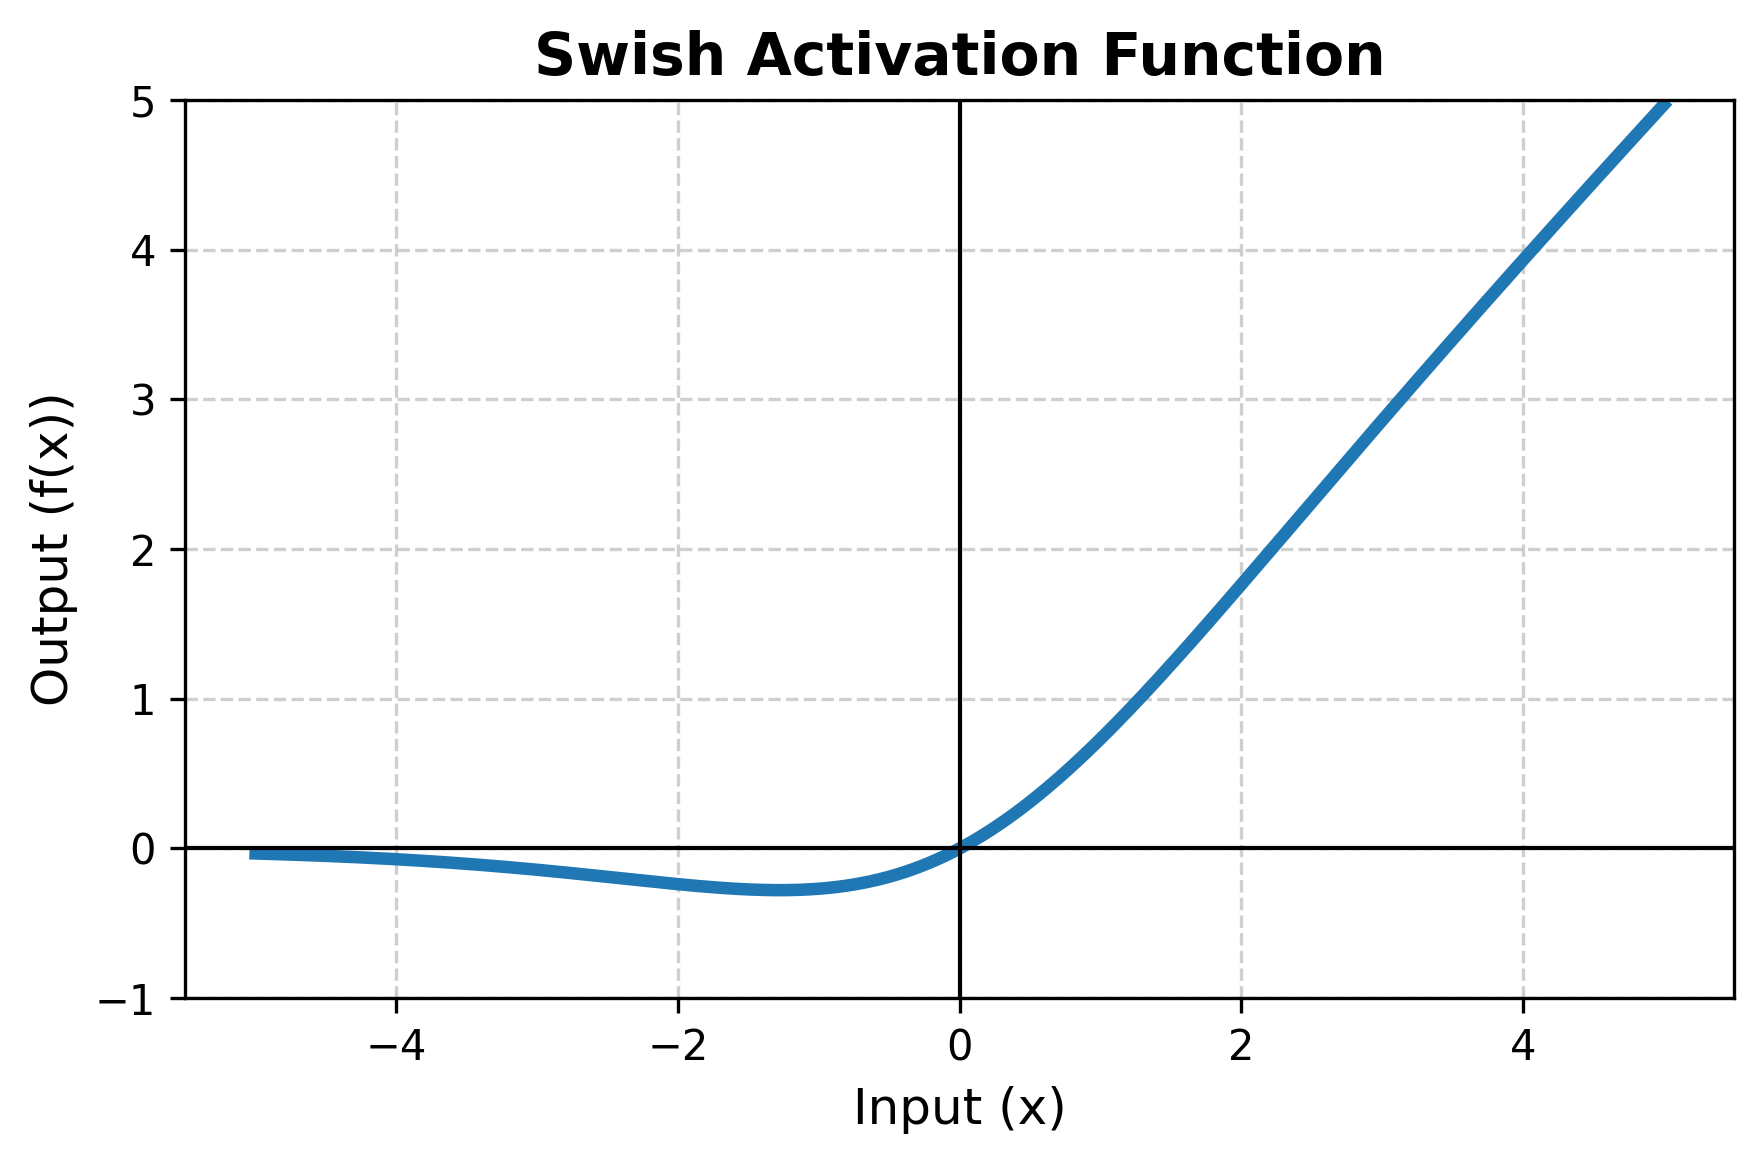

*   **Pros:** Consistently yields improvements in modern Convolutional Neural Networks (CNNs) and deep vision architectures. The slight negative dip preserves helpful structural information, making it excellent for complex computer vision tasks.
*   **Cons:** Higher computational cost compared to the ReLU family.
---
### 7. GELU (Gaussian Error Linear Unit)
GELU scales the input by the probability of the input under a normal distribution, essentially weighting inputs by how likely they are to drop off to zero.

$$f(x)=x\cdot\Phi(x)$$

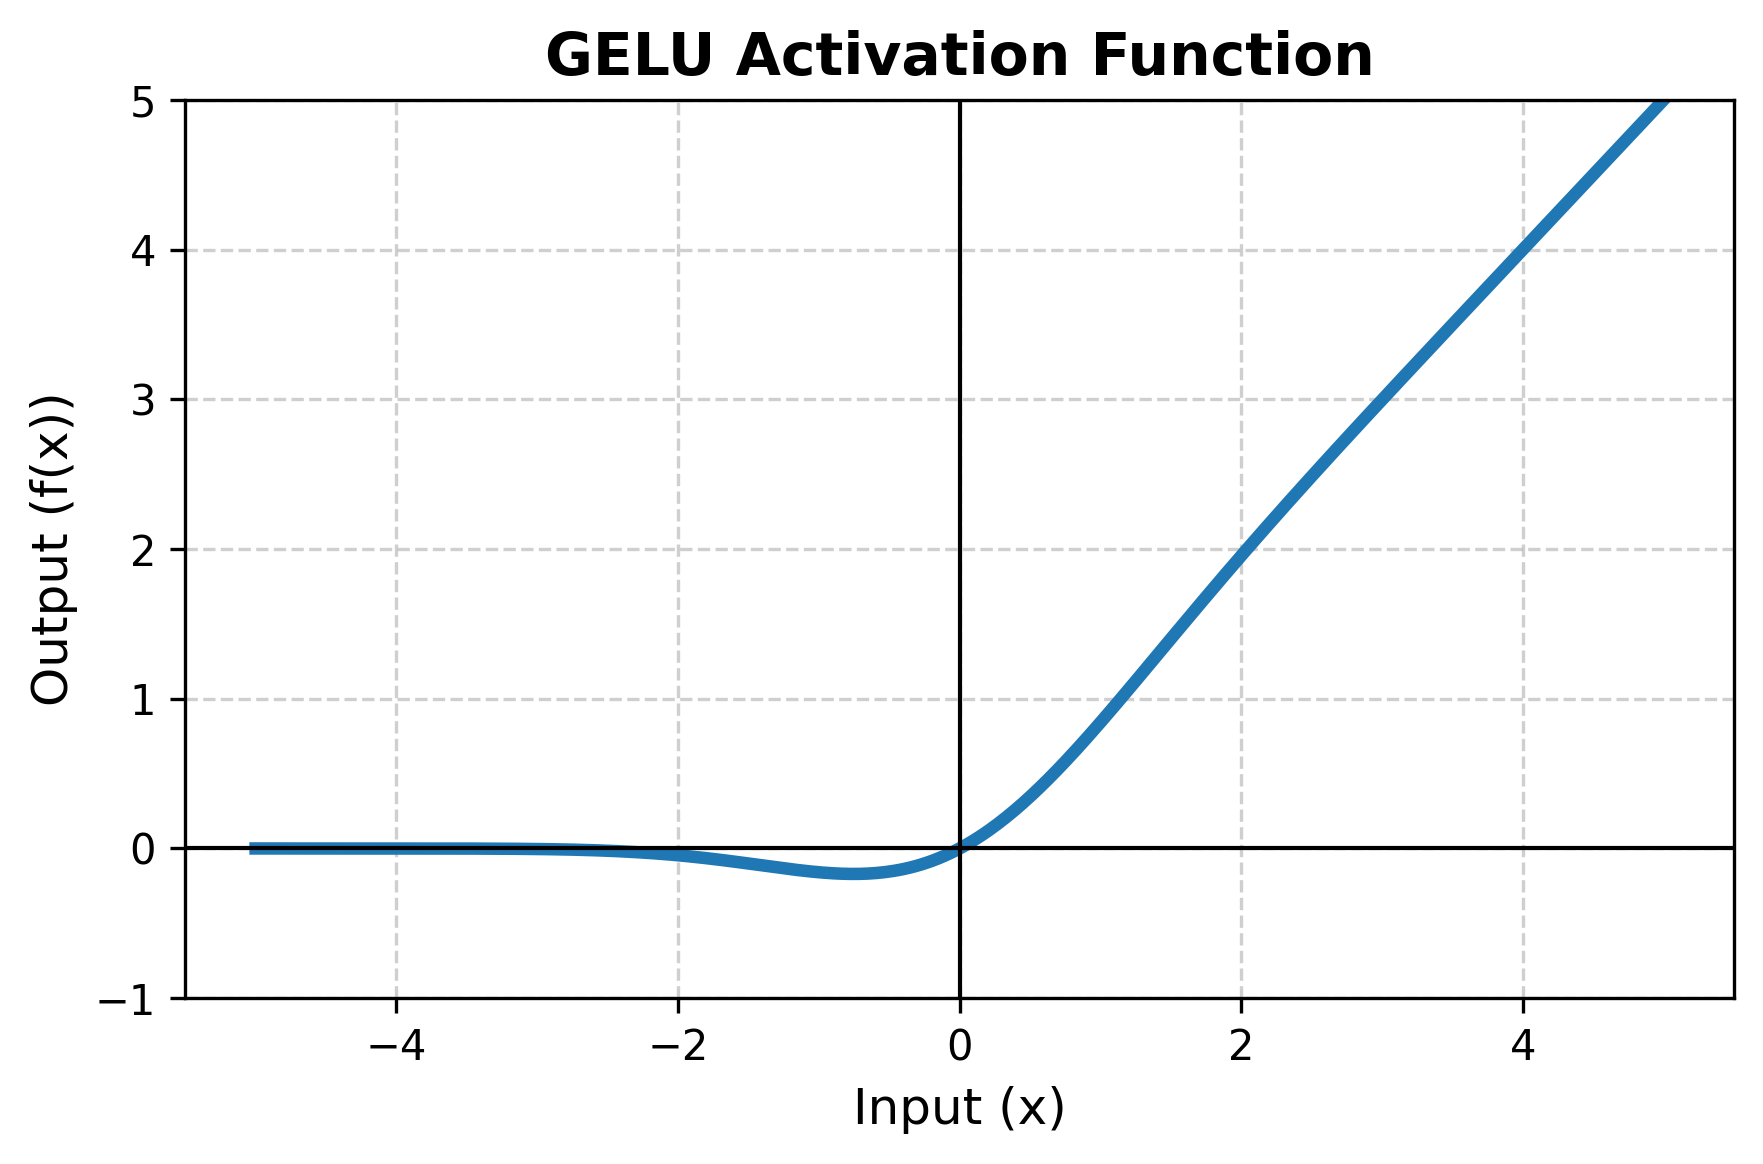

*   **Pros:** The industry standard for state-of-the-art architectures, particularly Vision-Language Models (VLMs) and Transformers.
*   **Cons:** Complex mathematical formulation that is heavily resource-intensive.
---
### 8. Softmax (Output Layer Only)
Unlike the functions above that look at a single neuron in isolation, Softmax takes a vector of raw scores from an entire layer and converts them into a probability distribution that sums exactly to $1.0$.

$$f(x_i)=\frac{e^{x_i}}{\sum_{j}e^{x_j}}$$


*   **Pros:** The absolute necessity for the final output layer of a multi-class classification model (e.g., categorizing an image into one of five different disease stages).

###  Activation Functions in PyTorch

PyTorch already provides most commonly used activation functions, so you rarely need to implement them from scratch. They are available in two main ways:

1. **As modules** (`torch.nn`)
2. **As functions** (`torch.nn.functional`)

#### 1. Activation Functions as Modules (`torch.nn`)

These are typically used when defining neural network architectures.

| Activation Function | PyTorch Module |
|---------------------|----------------|
| ReLU | `nn.ReLU()` |
| Sigmoid | `nn.Sigmoid()` |
| Tanh | `nn.Tanh()` |
| Leaky ReLU | `nn.LeakyReLU()` |
| ELU | `nn.ELU()` |
| SELU | `nn.SELU()` |
| GELU | `nn.GELU()` |
| SiLU (Swish) | `nn.SiLU()` |
| Mish | `nn.Mish()` |
| Softplus | `nn.Softplus()` |
| Softsign | `nn.Softsign()` |
| Hardtanh | `nn.Hardtanh()` |
| ReLU6 | `nn.ReLU6()` |
| Softmax | `nn.Softmax(dim=...)` |
| LogSoftmax | `nn.LogSoftmax(dim=...)` |

#### 2. Activation Functions as Functional APIs (`torch.nn.functional`)

The functional API is commonly imported as:

```python
import torch.nn.functional as F
```

Common activation functions include:

```python
F.relu(x)
F.sigmoid(x)
F.tanh(x)
F.leaky_relu(x)
F.elu(x)
F.gelu(x)
F.silu(x)
F.mish(x)
F.softmax(x, dim=1)
F.log_softmax(x, dim=1)
```

### Visualising Activation Functions

The plots below compare all key activation functions side by side — their shape, output range, and behaviour are fundamental to understanding how neurons fire in a network.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

x = np.linspace(-6, 6, 500)

# Define activations and their derivatives
activations = {
    'Sigmoid': (
        lambda x: 1 / (1 + np.exp(-x)),
        lambda x: (1 / (1 + np.exp(-x))) * (1 - 1 / (1 + np.exp(-x))),
        'Range: (0, 1)\nVanishing grad risk'
    ),
    'Tanh': (
        lambda x: np.tanh(x),
        lambda x: 1 - np.tanh(x)**2,
        'Range: (-1, 1)\nZero-centered'
    ),
    'ReLU': (
        lambda x: np.maximum(0, x),
        lambda x: (x > 0).astype(float),
        'Range: [0, ∞)\nDying ReLU risk'
    ),
    'Leaky ReLU': (
        lambda x: np.where(x > 0, x, 0.01 * x),
        lambda x: np.where(x > 0, 1.0, 0.01),
        'Range: (-∞, ∞)\nFixes dying ReLU'
    ),
    'ELU': (
        lambda x: np.where(x > 0, x, 1.0 * (np.exp(x) - 1)),
        lambda x: np.where(x > 0, 1.0, 1.0 * np.exp(x)),
        'Range: (-1, ∞)\nSmooth negative'
    ),
    'GELU': (
        lambda x: 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3))),
        None,
        'Range: (-∞, ∞)\nUsed in Transformers'
    ),
    'Swish / SiLU': (
        lambda x: x / (1 + np.exp(-x)),
        None,
        'Range: (-∞, ∞)\nSmooth, non-monotonic'
    ),
    'Softplus': (
        lambda x: np.log1p(np.exp(x)),
        lambda x: 1 / (1 + np.exp(-x)),
        'Range: (0, ∞)\nSmooth ReLU approx'
    ),
}

n = len(activations)
cols = 4
rows = (n + cols - 1) // cols  # ceiling division

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.2))
axes = axes.flatten()

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52',
          '#8172B2', '#937860', '#DA8BC3', '#8C8C8C']

for idx, (name, (fn, dfn, note)) in enumerate(activations.items()):
    ax = axes[idx]
    y = fn(x)
    ax.plot(x, y, color=colors[idx % len(colors)], linewidth=2.5, label='f(x)')
    if dfn is not None:
        dy = dfn(x)
        ax.plot(x, dy, color=colors[idx % len(colors)], linewidth=1.5,
                linestyle='--', alpha=0.6, label="f'(x)")
    ax.axhline(0, color='black', linewidth=0.7, alpha=0.4)
    ax.axvline(0, color='black', linewidth=0.7, alpha=0.4)
    ax.set_title(name, fontsize=11, fontweight='bold', pad=4)
    ax.set_xlim(-6, 6)
    ax.set_xlabel('x', fontsize=9)
    ax.legend(fontsize=8, loc='upper left')
    ax.text(0.98, 0.05, note, transform=ax.transAxes,
            fontsize=7.5, ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

# Hide unused subplots
for idx in range(len(activations), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Activation Functions & Their Derivatives', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (841619579.py, line 3)

## The Loss Function

Once forward propagation generates a prediction, the neural network needs a way to evaluate its own performance. The **Loss Function** (also called the Cost Function or Objective Function) provides exactly that: a mathematical measurement of how "wrong" the network's prediction is compared to the actual, true target.

If forward propagation is the network taking a test, the loss function is the grading rubric. The overarching goal of training a neural network is to **minimize this loss**.

### The Mathematical Objective
In formal notation, a loss function $L$ takes the network's prediction $\hat{y}$ and the true label $y$, and outputs a single scalar value representing the error:

$$Loss=L(\hat{y},y)$$

When we calculate the average loss across the entire training dataset (or a training batch), it is generally referred to as the **Cost Function**, denoted as $J(W,b)$, because the total error is ultimately a function of the network's current weights and biases.

### Core Types of Loss Functions
The choice of loss function is dictated entirely by the architecture of your model and the task you are trying to solve.

#### 1. Mean Squared Error (MSE) - For Regression
Regression tasks involve predicting continuous numerical values. For example, if you are designing a 2D Human Pose Estimation (HPE) system and need the network to predict the exact $(x,y)$ pixel coordinates of a patient's joints from a clinical video feed, you would use MSE.

MSE calculates the average of the squared differences between the predicted values and the actual values.

$$MSE=\frac{1}{N}\sum_{i=1}^{N}(y_i-\hat{y}_i)^2$$

*   $N$: The number of samples.
*   $y_i$: The true value (e.g., actual joint coordinate).
*   $\hat{y}_i$: The model's predicted value.
*   **Why square the error?** It ensures negative and positive errors do not cancel each other out, and it exponentially penalizes predictions that are wildly inaccurate.

#### 2. Binary Cross-Entropy (BCE) - For Binary Classification
When your network needs to make a yes/no decision—such as classifying whether a medical scan running on an edge device shows a specific anomaly ($1$) or not ($0$)—you use Binary Cross-Entropy. It evaluates how close the predicted probability (a value between 0 and 1) is to the actual class.

$$BCE=-\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log(\hat{y}_i)+(1-y_i)\log(1-\hat{y}_i)\right]$$

*   If the true class $y_i$ is $1$, the second half of the equation drops out, and the loss strictly penalizes the network if the predicted probability $\hat{y}_i$ is close to $0$.
*   If the true class is $0$, the first half drops out, penalizing the network if it confidently predicts a $1$.

#### 3. Categorical Cross-Entropy - For Multi-Class Classification
If the healthcare solution must categorize data into more than two distinct classes (e.g., diagnosing a scan as Stage 1, Stage 2, or Stage 3), this extension of BCE is used. It is almost always paired with the Softmax activation function in the final layer.

$$CCE=-\sum_{i=1}^{C}y_i\log(\hat{y}_i)$$

*   $C$: The total number of classes.
*   $y_i$: A binary indicator ($0$ or $1$) representing if class label $i$ is the correct ground-truth classification.
*   $\hat{y}_i$: The predicted probability for class $i$.

### Why not just use "Accuracy" as a Loss Function?
Accuracy (the percentage of correct guesses) is great for human evaluation, but it is a terrible loss function for a machine. Accuracy is discrete—a prediction is either right or wrong. It does not tell the network *how close* it was to being right.

Loss functions provide a smooth, continuous gradient. If the network predicts an anomaly probability of $0.49$ (which rounds to $0$, incorrectly), accuracy simply says "Wrong." Cross-Entropy loss says, "You were wrong, but you were very close to the $0.5$ threshold, so shift the weights just a tiny bit in this direction." This smooth, quantifiable feedback is what makes backpropagation possible.

## Automatic Differentiation and Backpropagation

At this point in the network's cycle, Forward Propagation has made a prediction, and the Loss Function has calculated exactly how wrong that prediction is.

But knowing the total error isn't enough. If an entire team fails a project, the manager needs to know *exactly* which team members made the mistakes so they can be corrected. In a neural network, we need to assign "blame" for the loss to every single weight and bias in the network. We do this by finding the **gradient** (the slope of the error).

### Backpropagation and the Chain Rule
**Backpropagation** (backward propagation of errors) is the algorithm we use to calculate these gradients. As the name suggests, it works in reverse. It starts at the final output loss and moves backward through the layers, layer by layer, until it reaches the input.

Mathematically, it relies entirely on a fundamental calculus concept called the **Chain Rule**.

If we want to know how much a specific weight ($w$) in an early layer impacted the final Loss ($L$), we can't calculate it directly. Instead, we multiply the cascading effects of everything that happened in between.

For a simple single-neuron output, the Chain Rule looks like this:

$$\frac{\partial L}{\partial w}=\frac{\partial L}{\partial a}\cdot\frac{\partial a}{\partial z}\cdot\frac{\partial z}{\partial w}$$

*   $\frac{\partial L}{\partial a}$: How did the final activation output affect the loss?
*   $\frac{\partial a}{\partial z}$: How did the raw weighted sum affect the activation output? (This is the derivative of the activation function).
*   $\frac{\partial z}{\partial w}$: How did the specific weight affect the raw sum?
*   $\frac{\partial L}{\partial w}$: The final gradient! This tells the optimizer exactly how to adjust this specific weight to lower the loss.

### Automatic Differentiation (AutoGrad)
If you were building neural networks in the 1990s or 2000s, you had to calculate all of these derivatives by hand and hardcode the calculus into your scripts. For a modern Deep Neural Network with millions of parameters, doing this by hand is mathematically impossible.

Today, we use **Automatic Differentiation** (often called **AutoGrad** in frameworks like PyTorch).

Here is how AutoGrad acts like magic behind the scenes:
1.  **The Computational Graph:** During the forward pass, the framework doesn't just calculate numbers; it builds a map (a Directed Acyclic Graph). It remembers every single tensor, every matrix multiplication, and every activation function used.
2.  **The Tape Recorder:** Think of it like a tape recorder that records the exact sequence of mathematical operations.
3.  **The Backward Pass:** When you call a command like `loss.backward()` in PyTorch, AutoGrad hits "rewind." It traverses the computational graph backward, automatically applying the Chain Rule to compute the exact gradients for every single weight in the network simultaneously.

Thanks to Automatic Differentiation, developers can focus entirely on designing the architecture of the network without ever having to manually derive complex matrix calculus!

### Training the Perceptron

In [ ]:
#Importing necessary packages


In [ ]:
n = 50
X, Y = make_classification(n_samples = n, n_features=2,
                           n_redundant=0, n_informative=2, flip_y=0)
Y = Y*2-1 # convert initial 0/1 values into -1/1
X = X.astype(np.float32); Y = Y.astype(np.int32) # features - float, label - int

# Split the dataset into training and test
train_x, test_x = np.split(X, [ n*8//10])
train_labels, test_labels = np.split(Y, [n*8//10])
print("Features:\n",train_x[0:4])
print("Labels:\n",train_labels[0:4])

In [ ]:
def plot_dataset(suptitle, features, labels):
    # prepare the plot
    fig, ax = pylab.subplots(1, 1)
    #pylab.subplots_adjust(bottom=0.2, wspace=0.4)
    fig.suptitle(suptitle, fontsize = 16)
    ax.set_xlabel('$x_i[0]$ -- (feature 1)')
    ax.set_ylabel('$x_i[1]$ -- (feature 2)')

    colors = ['r' if l>0 else 'b' for l in labels]
    ax.scatter(features[:, 0], features[:, 1], marker='o', c=colors, s=100, alpha = 0.5)
    fig.show()

plot_dataset('Training data', train_x, train_labels)

## Putting it Together: The Training Loop